In [1]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# ============================================
# DEVICE + SEED
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.manual_seed(42)

Using device: cuda


In [3]:
# ============================================
# PATHS
# ============================================
DATA_DIR = "../data/raw/fer2013"
train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Test dir exists: True


In [4]:
# ============================================
# IMPROVED TRANSFORMS - MORE AUGMENTATION
# ============================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Enhanced augmentation to reduce overfitting
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),  # Increased from 10
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # NEW: slight translation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),  # Increased
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))  # NEW: random erasing (must be after ToTensor)
])

test_transform = val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [5]:
# ============================================
# DATASETS + TRAIN/VAL SPLIT
# ============================================
base_train = datasets.ImageFolder(root=train_dir, transform=val_transform)

val_ratio = 0.15
n_total = len(base_train)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_train, [n_train, n_val], generator=g)

train_ids = train_subset.indices
val_ids = val_subset.indices

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=train_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_final = Subset(train_dataset, train_ids)
val_final = Subset(val_dataset, val_ids)

classes = base_train.classes
num_classes = len(classes)

print("Train:", len(train_final))
print("Val:", len(val_final))
print("Test:", len(test_dataset))
print("Classes:", classes)

Train: 24403
Val: 4306
Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
# ============================================
# DATALOADERS
# ============================================
BATCH_SIZE = 64

train_loader = DataLoader(
    train_final,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_final,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [7]:
# ============================================
# IMPROVED MODEL WITH DROPOUT
# ============================================
class ImprovedResNet18(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(ImprovedResNet18, self).__init__()
        weights = models.ResNet18_Weights.DEFAULT
        self.resnet = models.resnet18(weights=weights)
        
        # Remove the original FC layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        
        # Add improved head with dropout and batch norm
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate * 0.5),  # Lower dropout for second layer
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.resnet(x)
        return self.classifier(features)

model = ImprovedResNet18(num_classes=num_classes, dropout_rate=0.5)
model = model.to(device)
print("Model architecture:")
print(model.classifier)

Model architecture:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.25, inplace=False)
  (5): Linear(in_features=256, out_features=7, bias=True)
)


In [8]:
# ============================================
# TRAINING HELPERS
# ============================================
def set_requires_grad(model, flag: bool):
    for p in model.parameters():
        p.requires_grad = flag

def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
# ============================================
# [A] PHASE A: FREEZE BACKBONE, TRAIN ONLY CLASSIFIER
# ============================================
print("\n" + "="*50)
print("PHASE A: Training classifier only")
print("="*50)

# Freeze ResNet backbone
for param in model.resnet.parameters():
    param.requires_grad = False

# Only train classifier
for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimiser = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=0.001,
    weight_decay=0.01
)

EPOCHS_A = 5
best_val_acc = 0
best_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS_A+1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = copy.deepcopy(model.state_dict())

    print(f"[A] Epoch {epoch:01d}/{EPOCHS_A} | train acc {t_acc:.4f} | val acc {v_acc:.4f} | best {best_val_acc:.4f}")


PHASE A: Training classifier only
[A] Epoch 1/5 | train acc 0.3126 | val acc 0.3451 | best 0.3451
[A] Epoch 2/5 | train acc 0.3236 | val acc 0.3795 | best 0.3795
[A] Epoch 3/5 | train acc 0.3291 | val acc 0.3693 | best 0.3795
[A] Epoch 4/5 | train acc 0.3343 | val acc 0.3890 | best 0.3890
[A] Epoch 5/5 | train acc 0.3312 | val acc 0.3699 | best 0.3890


In [ ]:
# ============================================
# [B] PHASE B: UNFREEZE DEEPER LAYERS WITH LR SCHEDULING
# ============================================
print("\n" + "="*50)
print("PHASE B: Fine-tuning with gradual unfreezing")
print("="*50)

# Unfreeze layer3, layer4, and classifier
for name, param in model.named_parameters():
    if "resnet.layer3" in name or "resnet.layer4" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Different learning rates for different parts
backbone_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "classifier" in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

optimiser = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 0.00005, 'weight_decay': 0.01},  # Lower LR for backbone
    {'params': classifier_params, 'lr': 0.0001, 'weight_decay': 0.01}   # Higher LR for classifier
])

# Learning rate scheduler - reduces LR when validation accuracy plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='max',
    factor=0.5,
    patience=2
)

EPOCHS_B = 15  # More epochs but with early stopping
patience = 5  # Increased patience
no_improve = 0

for epoch in range(1, EPOCHS_B+1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    # Step the scheduler based on validation accuracy
    scheduler.step(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(f"[B] Epoch {epoch:02d}/{EPOCHS_B} | train acc {t_acc:.4f} | val acc {v_acc:.4f} | best {best_val_acc:.4f} | no_improve {no_improve}/{patience}")

    if no_improve >= patience:
        print("Early stopping triggered")
        break

# Load best model
model.load_state_dict(best_state)
print(f"\nLoaded best model. Best val accuracy: {best_val_acc:.4f}")


PHASE B: Fine-tuning with gradual unfreezing


c:\Users\Luka\miniconda3\envs\fer-dl\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[B] Epoch 01/15 | train acc 0.4819 | val acc 0.5745 | best 0.5745 | no_improve 0/5
[B] Epoch 02/15 | train acc 0.5618 | val acc 0.6180 | best 0.6180 | no_improve 0/5
[B] Epoch 03/15 | train acc 0.5973 | val acc 0.6296 | best 0.6296 | no_improve 0/5
[B] Epoch 04/15 | train acc 0.6202 | val acc 0.6317 | best 0.6317 | no_improve 0/5
[B] Epoch 05/15 | train acc 0.6361 | val acc 0.6442 | best 0.6442 | no_improve 0/5
[B] Epoch 06/15 | train acc 0.6523 | val acc 0.6519 | best 0.6519 | no_improve 0/5
[B] Epoch 07/15 | train acc 0.6662 | val acc 0.6593 | best 0.6593 | no_improve 0/5
[B] Epoch 08/15 | train acc 0.6805 | val acc 0.6595 | best 0.6595 | no_improve 0/5
[B] Epoch 09/15 | train acc 0.6892 | val acc 0.6612 | best 0.6612 | no_improve 0/5
[B] Epoch 10/15 | train acc 0.6994 | val acc 0.6616 | best 0.6616 | no_improve 0/5
[B] Epoch 11/15 | train acc 0.7079 | val acc 0.6623 | best 0.6623 | no_improve 0/5
[B] Epoch 12/15 | train acc 0.7201 | val acc 0.6677 | best 0.6677 | no_improve 0/5
[B] 

In [12]:
# ============================================
# TEST EVALUATION
# ============================================
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


TEST SET EVALUATION
Test Loss: 1.1377
Test Accuracy: 0.6768


In [13]:
# ============================================
# DETAILED METRICS
# ============================================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))


Classification Report:
              precision    recall  f1-score   support

       angry     0.5717    0.6159    0.5930       958
     disgust     0.6438    0.4234    0.5109       111
        fear     0.6099    0.3955    0.4799      1024
       happy     0.8773    0.8703    0.8738      1774
     neutral     0.5931    0.7364    0.6570      1233
         sad     0.5626    0.5477    0.5551      1247
    surprise     0.7533    0.8195    0.7850       831

    accuracy                         0.6768      7178
   macro avg     0.6588    0.6298    0.6364      7178
weighted avg     0.6769    0.6768    0.6716      7178



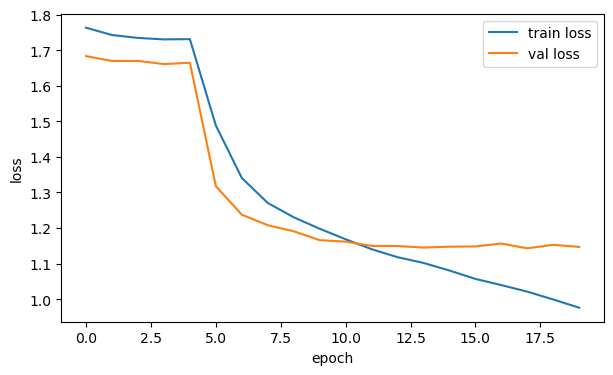

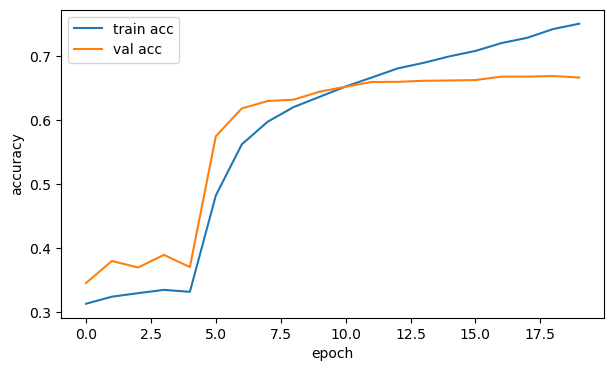

In [18]:
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.show()

Confusion matrix saved to confusion_matrix.png


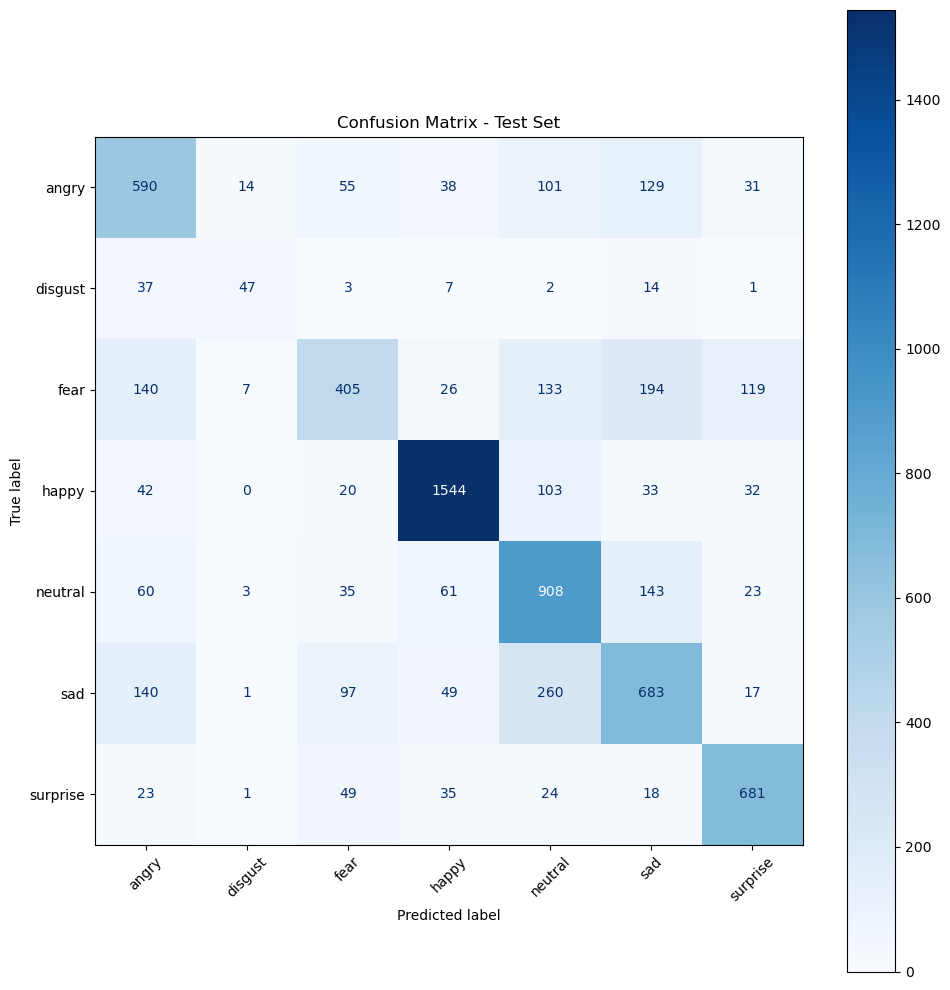

In [15]:
# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/best_confusion_matrix.png', dpi=150, bbox_inches='tight')
print("Confusion matrix saved to confusion_matrix.png")

Training curves saved to training_curves.png


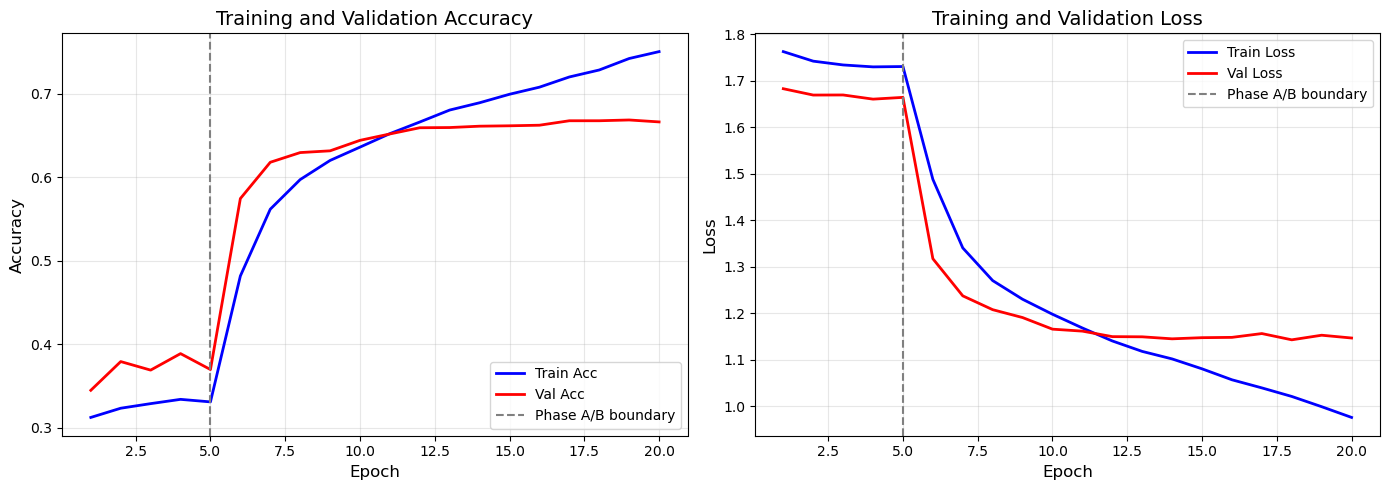

In [16]:
# ============================================
# TRAINING CURVES
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_acc"]) + 1)

# Accuracy plot
ax1.plot(epochs, history["train_acc"], 'b-', label='Train Acc', linewidth=2)
ax1.plot(epochs, history["val_acc"], 'r-', label='Val Acc', linewidth=2)
ax1.axvline(x=EPOCHS_A, color='gray', linestyle='--', label='Phase A/B boundary')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training and Validation Accuracy', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs, history["train_loss"], 'b-', label='Train Loss', linewidth=2)
ax2.plot(epochs, history["val_loss"], 'r-', label='Val Loss', linewidth=2)
ax2.axvline(x=EPOCHS_A, color='gray', linestyle='--', label='Phase A/B boundary')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training and Validation Loss', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/best_training_curves.png', dpi=150, bbox_inches='tight')
print("Training curves saved to training_curves.png")

In [17]:
# ============================================
# SUMMARY STATISTICS
# ============================================
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Overfitting Gap (Train - Val): {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")
print(f"Generalization Gap (Val - Test): {best_val_acc - test_acc:.4f}")

# Save the model
torch.save(model.state_dict(), '../models/best_model.pth')
print("\nModel saved to improved_model.pth")

print("\n" + "="*50)
print("IMPROVEMENTS IMPLEMENTED:")
print("="*50)
print("1. Enhanced data augmentation (rotation, translation, random erasing)")
print("2. Dropout layers (0.5 and 0.25) in classifier")
print("3. Batch normalization in classifier")
print("4. AdamW optimizer with increased weight decay (0.01)")
print("5. Differential learning rates (lower for backbone, higher for classifier)")
print("6. Learning rate scheduler (ReduceLROnPlateau)")
print("7. Increased early stopping patience (5 epochs)")
print("8. More epochs allowed with better monitoring")
print("="*50)


SUMMARY
Best Validation Accuracy: 0.6686
Test Accuracy: 0.6768
Overfitting Gap (Train - Val): 0.0841
Generalization Gap (Val - Test): -0.0082

Model saved to improved_model.pth

IMPROVEMENTS IMPLEMENTED:
1. Enhanced data augmentation (rotation, translation, random erasing)
2. Dropout layers (0.5 and 0.25) in classifier
3. Batch normalization in classifier
4. AdamW optimizer with increased weight decay (0.01)
5. Differential learning rates (lower for backbone, higher for classifier)
6. Learning rate scheduler (ReduceLROnPlateau)
7. Increased early stopping patience (5 epochs)
8. More epochs allowed with better monitoring
